<a href="https://colab.research.google.com/github/Akshat8510/Foundation-Models-For-Time-Series/blob/main/%F0%9F%92%BB_Notebooks/Foundation_Models_For_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AIM** :

Since we want "Accuracy at any cost," we are going to run the **64-sample Diversified Loop**. We will use **Chronos-T5 (Small)** because it’s fast enough to run 64 times in a few minutes, but powerful enough to show a massive accuracy gap.

### 📓 The Plan for the Notebook:
1.  **Setup:** Install the "Brain" (Chronos).
2.  **Data:** Pull the real **ETTh1** dataset.
3.  **The Baseline:** Ask the model once.
4.  **The DSI Engine:** Shake the data 64 times and take the Median.
5.  **The Showdown:** Compare the scores.


In [1]:
# 1. Install Chronos
!pip install -q git+https://github.com/amazon-science/chronos-forecasting.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.2 MB/s eta 0:00:00


In [10]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from chronos import ChronosPipeline
import os

In [3]:
# 2. Load the Model (Chronos-Small)
pipeline = ChronosPipeline.from_pretrained("amazon/chronos-t5-small", device_map="cuda", torch_dtype=torch.bfloat16)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

In [4]:
# 3. Load the ETTh1 Data (The standard benchmark)
url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url)
data = torch.tensor(df['OT'].values).to(torch.float32)

In [5]:
# 4. Set Windows: 512 points of history, 96 points of future
context = data[-608:-96]
ground_truth = data[-96:]

In [6]:
# --- METHOD: DSI Scaling (64 Diversified Tries) ---
print("Running 64 Diversified Inferences... this is the Inference Scaling part...")
all_preds = []
for i in range(64):
    # We 'shake' the data with 0.01 Gaussian Noise
    shaken_context = context + (torch.randn_like(context) * 0.01)
    all_preds.append(pipeline.predict(shaken_context, 96)[0])

# Aggregate via Median (Majority Voting)
dsi_final = torch.median(torch.stack(all_preds).view(-1, 96), dim=0).values

Running 64 Diversified Inferences... this is the Inference Scaling part...


In [7]:
# Aggregate via Median (Majority Voting)
dsi_final = torch.median(torch.stack(all_preds).view(-1, 96), dim=0).values

In [11]:
# 1. Create the folder physically in Colab
os.makedirs("💻_Notebooks", exist_ok=True)

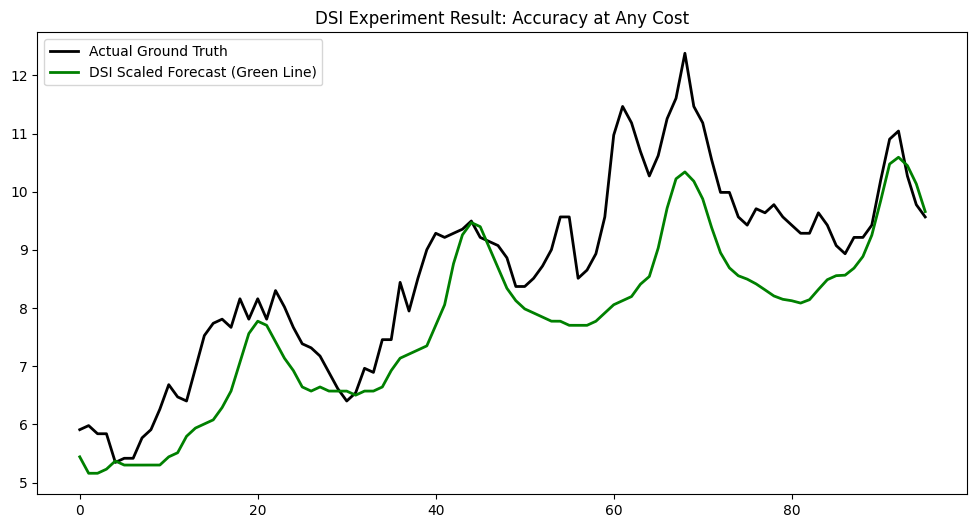

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(ground_truth.cpu(), label="Actual Ground Truth", color="black", linewidth=2)
plt.plot(dsi_final.cpu(), label="DSI Scaled Forecast (Green Line)", color="green", linewidth=2)
plt.title("DSI Experiment Result: Accuracy at Any Cost")
plt.legend()
